#preprocessing

In [1]:
#database installation
!pip -q install opendatasets
from pathlib import Path
import opendatasets as od

RAW = Path("/content/data"); RAW.mkdir(parents=True, exist_ok=True)
od.download("https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated",
            data_dir=str(RAW/"plant_village_updated"))
print("Ready at:", RAW/"plant_village_updated")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: salo7asait 
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated


100%|██████████| 1.00G/1.00G [00:00<00:00, 1.66GB/s]



Ready at: /content/data/plant_village_updated


In [2]:
#  Total number of images
from pathlib import Path
import os, shutil, re, numpy as np

# # Root dataset directory
ROOT = Path("/content/data/plant_village_updated")
assert ROOT.exists(), f"المجلد غير موجود: {ROOT}"
# Detects when the dataset resides inside a single nested folder
subdirs = [d for d in ROOT.iterdir() if d.is_dir()]
if len(subdirs) == 1 and not (ROOT/"train").exists():
    ROOT = subdirs[0]
print("Using dataset root:", ROOT)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_image(p: Path):
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean_text(s: str):
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

#  Unified output directory
UNIFIED = ROOT.parent / (ROOT.name + "_unified")
if UNIFIED.exists():
    shutil.rmtree(UNIFIED)
for sp in ["train","val","test"]:
    (UNIFIED/sp).mkdir(parents=True, exist_ok=True)

# Possible split aliases
SPLIT_ALIASES = {
    "train": ["train","Train","TRAIN","training","Training"],
    "val":   ["val","Val","valid","Valid","validation","Validation"],
    "test":  ["test","Test","TEST","testing","Testing"],
}

rng = np.random.default_rng(42)

def copy_images(src_files, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img in src_files:
        tgt = dst_dir / img.name
        # إن وجد اسم مكرر، ضف لاحقة
        if tgt.exists():
            stem, suf = tgt.stem, tgt.suffix
            k = 1
            while (dst_dir / f"{stem}_{k}{suf}").exists():
                k += 1
            tgt = dst_dir / f"{stem}_{k}{suf}"
        shutil.copy2(img, tgt)

# Process each crop category
crops = [d for d in ROOT.iterdir() if d.is_dir()]
total_copied = 0
for crop in crops:
    crop_name = clean_text(crop.name)

    # Detect if crop contains predefined train/val/test folders
    found_split = False
    split_dirs = {}
    for split_key, aliases in SPLIT_ALIASES.items():
        for name in aliases:
            cand = crop / name
            if cand.exists():
                split_dirs[split_key] = cand
                found_split = True
                break

    if found_split:
        # Use existing split structure
        for split_key, split_dir in split_dirs.items():
            for disease_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
                disease_name = clean_text(disease_dir.name)
                class_name = f"{crop_name} - {disease_name}"
                files = [p for p in disease_dir.rglob("*") if is_image(p)]
                copy_images(files, UNIFIED / split_key / class_name)
                total_copied += len(files)
    else:
        #  No predefined split → apply manual 70/15/15 split
        disease_dirs = [d for d in crop.iterdir() if d.is_dir()]
        for disease_dir in disease_dirs:
            disease_name = clean_text(disease_dir.name)
            class_name = f"{crop_name} - {disease_name}"
            files = [p for p in disease_dir.rglob("*") if is_image(p)]
            if not files:
                continue
            rng.shuffle(files)
            n = len(files)
            n_train = int(n * 0.70)
            n_val   = int(n * 0.15)
            n_test  = n - n_train - n_val
            splits = {
                "train": files[:n_train],
                "val"  : files[n_train:n_train+n_val],
                "test" : files[n_train+n_val:]
            }
            for split_key, group in splits.items():
                copy_images(group, UNIFIED / split_key / class_name)
            total_copied += n

print("Unified dataset built at:", UNIFIED)
print("Total copied images:", total_copied)


Using dataset root: /content/data/plant_village_updated/plant-village-dataset-updated
Unified dataset built at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
Total copied images: 67118


In [3]:
# Total number of images in train, val, and test
# Listing all class names for each crop

from collections import defaultdict
import pandas as pd

# 1- Automatically determine the dataset root (either DATA_DIR or UNIFIED)
ROOT = None
for cand in [globals().get("DATA_DIR"), globals().get("UNIFIED")]:
    if cand is None:
        continue
    cand = Path(cand)
    if (cand/"train").exists():
        ROOT = cand
        break
assert ROOT is not None, "حددي ROOT: إما DATA_DIR (من resplit) أو UNIFIED (من التوحيد) ويحتوي مجلد train/."

#2- Helper functions
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def count_images_dir(d: Path) -> int:
    return sum(1 for p in d.rglob("*") if is_image(p))

#3- Determine available splits based on folder structure
splits = ["train","val"] + (["test"] if (ROOT/"test").exists() else [])

# 4- Calculations for each class in the format "Crop - Disease" + grouping by crop
by_crop = defaultdict(list)
rows = []

train_class_dirs = sorted([d for d in (ROOT/"train").iterdir() if d.is_dir()], key=lambda x: x.name)

for d in train_class_dirs:
    name = d.name
    if " - " in name:
        crop_name, disease = name.split(" - ", 1)
    else:
        parts = name.split()
        crop_name, disease = parts[0], " ".join(parts[1:]) if len(parts)>1 else "(Unknown)"

    counts = {s: count_images_dir(ROOT/s/name) for s in splits}
    counts["total"] = sum(counts.values())

    by_crop[crop_name].append((disease, name, counts))
    rows.append({
        "crop": crop_name,
        "class_name": name,
        "disease": disease,
        **{s: counts[s] for s in splits},
        "total": counts["total"]
    })

#5- Print detailed class breakdown per crop
print("\n Classes by crop (with image counts):")
for crop_name in sorted(by_crop.keys()):
    items = sorted(by_crop[crop_name], key=lambda x: x[0])
    crop_tot = {s: sum(it[2][s] for it in items) for s in splits}
    crop_tot["total"] = sum(crop_tot.values())
    header = " | ".join([f"{s}={crop_tot[s]}" for s in splits] + [f"total={crop_tot['total']}"])
    print(f"\n{crop_name} ({len(items)} classes) [{header}]")
    for i, (dz, class_name, cnts) in enumerate(items, 1):
        line = " | ".join([f"{s}:{cnts[s]}" for s in splits] + [f"Σ:{cnts['total']}"])
        print(f"  {i:2d}. {dz} -> {line}")

# 6- save as result CSV
df = pd.DataFrame(rows)
csv_path = ROOT / "class_counts_by_crop.csv"
df.to_csv(csv_path, index=False)
print("\n Saved counts table to:", csv_path)

# 7- Compute overall image totals per split and the global total
totals = {s: count_images_dir(ROOT/s) for s in splits}
grand_total = sum(totals.values())
print("\n Totals (images per split):")
for s in splits:
    print(f"  {s:<5} = {totals[s]}")
print(f"  total = {grand_total}")



 Classes by crop (with image counts):

Apple (4 classes) [train=7771 | val=1747 | test=196 | total=9714]
   1. Apple Scab -> train:2016 | val:453 | test:51 | Σ:2520
   2. Black Rot -> train:1987 | val:447 | test:50 | Σ:2484
   3. Cedar Apple Rust -> train:1760 | val:396 | test:44 | Σ:2200
   4. Healthy -> train:2008 | val:451 | test:51 | Σ:2510

Bell Pepper (2 classes) [train=3901 | val=877 | test=98 | total=4876]
   1. Bacterial Spot -> train:1913 | val:430 | test:48 | Σ:2391
   2. Healthy -> train:1988 | val:447 | test:50 | Σ:2485

Cherry (2 classes) [train=3509 | val=788 | test=89 | total=4386]
   1. Healthy -> train:1826 | val:410 | test:46 | Σ:2282
   2. Powdery Mildew -> train:1683 | val:378 | test:43 | Σ:2104

Corn (Maize) (4 classes) [train=7316 | val=1645 | test=188 | total=9149]
   1. Cercospora Leaf Spot -> train:1642 | val:369 | test:45 | Σ:2056
   2. Common Rust -> train:1907 | val:429 | test:48 | Σ:2384
   3. Healthy -> train:1859 | val:418 | test:47 | Σ:2324
   4. North

In [4]:
#  Unifing / Renaming

from pathlib import Path
import shutil, re
from collections import Counter
import pandas as pd

# --------General settings (paths and image extensions)--------
SRC = Path("/content/data/plant_village_updated/plant-village-dataset-updated")  # Source
DST = SRC.parent / (SRC.name + "_unified")                                      # Output folder
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
SPLITS = {"train","val","test"}  # إن وُجدت

DST.mkdir(parents=True, exist_ok=True)

def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean(s: str) -> str:
    s = s.replace("_", " ")
    s = re.sub(r"[()]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def split_plant_disease(name: str):
    """Extract plant and disease labels from folder names."""
    n = clean(name)

    # Patterns 'Plant - Disease'
    if " - " in n:
        plant, disease = n.split(" - ", 1)
        return clean(plant), clean(disease)


    plants = [
        "Apple","Bell Pepper","Cherry","Corn (Maize)","Corn Maize","Grape",
        "Peach","Potato","Strawberry","Tomato"
    ]
    for plant in plants:
        if n.lower().startswith(plant.lower()):
            disease = clean(n[len(plant):])
            plant = "Corn (Maize)" if plant.lower() in {"corn maize","corn (maize)"} else plant
            return plant, disease

    return None, None

def iter_leaf_folders(base: Path):

    """Locate image folders and infer their labels."""

    for plant_dir in base.iterdir():
        if not plant_dir.is_dir():
            continue

        # Case: "Plant - Disease"
        p_plant, p_dis = split_plant_disease(plant_dir.name)
        if p_plant and p_dis and any(is_image(x) for x in plant_dir.rglob("*")):
            yield (p_plant, p_dis, plant_dir)
            continue


        plant_name = clean(plant_dir.name)


        subdirs = [d for d in plant_dir.iterdir() if d.is_dir()]
        if not subdirs: # images directly inside plant folder

            if any(is_image(x) for x in plant_dir.iterdir()):
                yield (plant_name, "", plant_dir)
            continue


        split_dirs = [d for d in subdirs if d.name.lower() in SPLITS]
        if split_dirs: # train/val/test structure
            for sp in split_dirs:
                for disease_dir in [d for d in sp.iterdir() if d.is_dir()]:
                    if any(is_image(x) for x in disease_dir.iterdir()):
                        yield (plant_name, clean(disease_dir.name), disease_dir)
            continue

       # plant/disease structure
        for disease_dir in subdirs:
            if any(is_image(x) for x in disease_dir.iterdir()):
                # ممكن يكون disease_dir اسمه "Plant - Disease"
                pp, dd = split_plant_disease(disease_dir.name)
                if pp and dd:
                    yield (pp, dd, disease_dir)
                else:
                    yield (plant_name, clean(disease_dir.name), disease_dir)

def unique_copy(src: Path, dst_dir: Path):

    """Copy image while preventing filename conflicts."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    name = src.name
    target = dst_dir / name
    if not target.exists():
        shutil.copy2(src, target)
        return target

    stem, suf = src.stem, src.suffix
    k = 1
    while True:
        cand = dst_dir / f"{stem}_{k}{suf}"
        if not cand.exists():
            shutil.copy2(src, cand)
            return cand
        k += 1

# -------- Execution --------
counts = Counter()
mappings = []   # (plant, disease, src_dir, dst_class, num_imgs)
unmatched = []

for plant, disease, src_dir in iter_leaf_folders(SRC):

    plant = clean(plant) if plant else ""
    disease = clean(disease) if disease else "Healthy"
    dst_class = f"{plant} {disease}".strip()
    dst_class = re.sub(r"\s+", " ", dst_class)

    n_before = counts[dst_class]
    for p in src_dir.iterdir():
        if is_image(p):
            unique_copy(p, DST / dst_class)
            counts[dst_class] += 1

    n_new = counts[dst_class] - n_before
    mappings.append((plant, disease, str(src_dir), dst_class, n_new))


    if not plant or dst_class.lower() in {"", "healthy"}:
        unmatched.append((plant or "?", disease or "?", str(src_dir)))

# -------- Reporting --------
print(f"Unified dataset created at: {DST}")
print(f"Total classes: {len(counts)}")
print(f" Total images: {sum(counts.values())}\n")

print("Classes & counts:")
for cls in sorted(counts):
    print(f"- {cls}: {counts[cls]}")


df = pd.DataFrame(mappings, columns=["plant","disease","src_dir","dst_class","copied_images"])
csv_path = DST / "unify_report.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\n Saved mapping report: {csv_path}")

if unmatched:
    print("\n Unmatched/weakly parsed entries (check and rerun if needed):")
    for plant, disease, src in unmatched[:30]:
        print(f"- plant='{plant}' disease='{disease}' from: {src}")
    if len(unmatched) > 30:
        print(f"... and {len(unmatched)-30} more")

Unified dataset created at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
Total classes: 29
 Total images: 67111

Classes & counts:
- Apple Apple Scab: 2520
- Apple Black Rot: 2484
- Apple Cedar Apple Rust: 2200
- Apple Healthy: 2510
- Bell Pepper Bacterial Spot: 2391
- Bell Pepper Healthy: 2485
- Cherry Healthy: 2282
- Cherry Powdery Mildew: 2104
- Corn Maize Cercospora Leaf Spot: 2052
- Corn Maize Common Rust: 2384
- Corn Maize Healthy: 2324
- Corn Maize Northern Leaf Blight: 2385
- Grape Black Rot: 2360
- Grape Esca Black Measles: 2400
- Grape Healthy: 2115
- Grape Leaf Blight: 2152
- Peach Bacterial Spot: 2297
- Peach Healthy: 2160
- Potato Early Blight: 2424
- Potato Healthy: 2280
- Potato Late Blight: 2424
- Strawberry Healthy: 2280
- Strawberry Leaf Scorch: 2218
- Tomato Bacterial Spot: 2127
- Tomato Early Blight: 2400
- Tomato Healthy: 2407
- Tomato Late Blight: 2314
- Tomato Septoria Leaf Spot: 2181
- Tomato Yellow Leaf Curl Virus: 2451

 Saved mapp

In [5]:
# Remove Duplicates
# ===== Remove Duplicates (phash) – fixed & safe =====
!pip -q install imagehash
from pathlib import Path
from PIL import Image, ImageFile
import imagehash, pandas as pd, shutil, collections, os

# 0) Settings
ImageFile.LOAD_TRUNCATED_IMAGES = True
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

# 1) Paths + Options
DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")
assert (DATA_DIR/"train").exists(), f"DATA_DIR غير موجود أو لا يحوي train: {DATA_DIR}"

REPORT_ONLY       = False
PREFER_SPLIT_KEEP = "train"

TRASH_DIR  = DATA_DIR.parent / (DATA_DIR.name + "_duplicates_trash")
REPORTS    = DATA_DIR / "_reports"
TRASH_DIR.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

# 2) Compute phash inside each split
def phashes_in_split(split: str):
    base = DATA_DIR / split
    hmap = collections.defaultdict(list)     # hash -> [paths]
    if not base.exists():
        return hmap
    for p in base.rglob("*"):
        if not is_image(p):
            continue
        try:
            with Image.open(p) as im:
                im = im.convert("RGB")
                h = str(imagehash.phash(im))
            hmap[h].append(p)
        except Exception as e:

            pass
    return hmap

splits_present = [s for s in ["train","val","test"] if (DATA_DIR/s).exists()]
h_by_split     = {s: phashes_in_split(s) for s in splits_present}

# 3) Duplicates within a single split
dups_within_rows = []
for s in splits_present:
    for h, paths in h_by_split[s].items():
        if len(paths) > 1:
            for p in paths:
                dups_within_rows.append([s, h, str(p)])

# 4) Duplicates across splits
h_sets = {s: set(h_by_split[s].keys()) for s in splits_present}
dups_across_rows, pairs = [], []
if "train" in h_sets and "val"  in h_sets: pairs.append(("train","val"))
if "train" in h_sets and "test" in h_sets: pairs.append(("train","test"))
if "val"   in h_sets and "test" in h_sets: pairs.append(("val","test"))

for a, b in pairs:
    inter = h_sets[a] & h_sets[b]
    for h in inter:
        for p in h_by_split[a][h]:
            dups_across_rows.append([a, b, h, str(p)])
        for p in h_by_split[b][h]:
            dups_across_rows.append([a, b, h, str(p)])

# 5) Save reports
df_within = pd.DataFrame(dups_within_rows, columns=["split","phash","path"])
df_across = pd.DataFrame(dups_across_rows, columns=["split_a","split_b","phash","path"])
csv_within = REPORTS / "duplicates_within_split.csv"
csv_across = REPORTS / "duplicates_across_splits.csv"
if not df_within.empty: df_within.to_csv(csv_within, index=False)
if not df_across.empty: df_across.to_csv(csv_across, index=False)
print(f" {len(df_within)} | : {len(df_across)}")
print("Saved:", (csv_within if not df_within.empty else "-"), "|",
               (csv_across if not df_across.empty else "-"))

# 6) Move duplicates to trash directory
def unique_in_trash(p: Path) -> Path:
    """ي TRASH_DIR ""
    stem, suf = p.stem, p.suffix
    dst = TRASH_DIR / (stem + suf)
    k = 1
    while dst.exists():
        dst = TRASH_DIR / f"{stem}_{k}{suf}"
        k += 1
    return dst

if not REPORT_ONLY:
    moved = 0
    # Within-split duplicates: keep first, move remaining
    for s in splits_present:
        for h, paths in h_by_split[s].items():
            if len(paths) > 1:
                for p in paths[1:]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1
    # Across-split duplicates: keep preferred split
    if PREFER_SPLIT_KEEP in h_sets:
        for other in [x for x in splits_present if x != PREFER_SPLIT_KEEP]:
            inter = h_sets[PREFER_SPLIT_KEEP] & h_sets[other]
            for h in inter:
                for p in h_by_split[other][h]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1
    print(f" moved {moved} duplicates -> {TRASH_DIR}")
else:
    print("Report-only mode: no files were moved.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.0 MB/s eta 0:00:00
داخل التقسيم (صفوف): 226 | بين التقسيمات (صفوف): 102
Saved: /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_within_split.csv | /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_across_splits.csv
 moved 165 duplicates -> /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [6]:
# Verify that no classes are empty after duplicate removal

from pathlib import Path
import pandas as pd, os

root = DATA_DIR  # unified dataset directory
trash = root.parent / (root.name + "_duplicates_trash")
print("TRASH_DIR =", trash)

# Regenerate duplicate reports in report-only mode
!pip -q install imagehash >/dev/null
REPORT_ONLY = True
# Re-run the previous duplicate-detection cell with this flag

# Check that each class in val/test contains at least one image
from torchvision.datasets import ImageFolder
from torchvision import transforms

val_classes  = sorted([d.name for d in (root/"val").iterdir() if d.is_dir()])
test_classes = sorted([d.name for d in (root/"test").iterdir()]) if (root/"test").exists() else []

def count_images(dirpath):
    exts = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
    return sum(1 for p in Path(dirpath).rglob("*") if p.suffix.lower() in exts)

bad_val  = [c for c in val_classes  if count_images(root/"val"/c) == 0]
bad_test = [c for c in test_classes if count_images(root/"test"/c) == 0]

print("empty in val :", len(bad_val))
print("empty in test:", len(bad_test))
if bad_val:  print(" ->", bad_val[:10], "...")
if bad_test: print(" ->", bad_test[:10], "...")

TRASH_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash
empty in val : 0
empty in test: 0


In [7]:
# Delete folder that contains Duplicates
import shutil, os
if os.path.isdir(trash):
    shutil.rmtree(trash)
    print("Deleted:", trash)
else:
    print(" No trash folder:", trash)

Deleted: /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [8]:

#Repartition dataset into 70/15/15 (train/val/test) for each class

from pathlib import Path
import numpy as np, shutil

OLD = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")
assert (OLD/"train").exists(), "*_unified"

R_TRAIN, R_VAL = 0.70, 0.15
R_TEST = 1.0 - R_TRAIN - R_VAL   # = 0.15
SEED = 42

NEW = OLD.parent / (OLD.name + "_resplit_70_15_15")
if NEW.exists(): shutil.rmtree(NEW)
for sp in ["train","val","test"]:
    (NEW/sp).mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS

def all_classes(root: Path):
    names=set()
    for sp in ["train","val","test"]:
        d=root/sp
        if d.exists(): names |= {x.name for x in d.iterdir() if x.is_dir()}
    return sorted(names)

def all_images_of_class(root: Path, cls: str):
    files=[]
    for sp in ["train","val","test"]:
        d=root/sp/cls
        if d.exists(): files += [p for p in d.rglob("*") if is_img(p)]
    return files

rng = np.random.default_rng(SEED)
totals = {"train":0,"val":0,"test":0}
classes = all_classes(OLD)

for cls in classes:
    files = all_images_of_class(OLD, cls)
    n = len(files)
    if n == 0:
        continue
    rng.shuffle(files)

    n_tr = int(round(n * R_TRAIN))
    n_va = int(round(n * R_VAL))
    n_te = n - n_tr - n_va

    if n >= 3:
        if n_tr == 0: n_tr = 1
        if n_va == 0: n_va = 1
        if n_te == 0: n_te = 1
        while n_tr + n_va + n_te > n:
            if   n_tr >= n_va and n_tr >= n_te: n_tr -= 1
            elif n_va >= n_tr and n_va >= n_te: n_va -= 1
            else: n_te -= 1
    elif n == 2:
        n_tr, n_va, n_te = 1, 1, 0
    else:  # n == 1
        n_tr, n_va, n_te = 1, 0, 0

    splits = {"train": files[:n_tr], "val": files[n_tr:n_tr+n_va], "test": files[n_tr+n_va:]}

    for sp, group in splits.items():
        out = NEW/sp/cls; out.mkdir(parents=True, exist_ok=True)
        for src in group:
            dst = out/src.name
            k=1
            while dst.exists():
                dst = out/f"{src.stem}_{k}{src.suffix}"; k+=1
            shutil.copy2(src, dst)
        totals[sp] += len(group)

print(" Resplit done at:", NEW)
print(" Totals:", totals, "| sum =", sum(totals.values()))

 # Use NEW as the DATA_DIR for training and evaluation
DATA_DIR = NEW

# # Summarize final image counts per split
def count_images_dir(d: Path):
    return sum(1 for p in d.rglob("*") if is_img(p))

splits = ["train","val","test"]
totals2 = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n Totals (images per split):")
for s in splits: print(f"  {s:<5} = {totals2[s]}")
print("  total =", sum(totals2.values()))


 Resplit done at: /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15
 Totals: {'train': 46868, 'val': 10047, 'test': 10038} | sum = 66953

 Totals (images per split):
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [9]:
#Archive the previous dataset split configuration
from pathlib import Path
import shutil

BASE = Path("/content/data/plant_village_updated")

OLD = BASE/"plant-village-dataset-updated_unified"                 # original split
NEW = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15" #  new split
ARCHIVE_DIR = BASE/"_archived_splits"
ARCHIVE_DIR.mkdir(exist_ok=True)

# Move old split to archive (outside the active training/processing path)
if OLD.exists():
    target = ARCHIVE_DIR/OLD.name
    if target.exists():
        shutil.rmtree(target)
    shutil.move(str(OLD), str(target))
    print(" moved OLD split to:", target)
else:
    print(" OLD split not found:", OLD)

#  Set the new split as the active DATA_DIR
assert NEW.exists(), f"NEW split not found: {NEW}"
DATA_DIR = NEW
print(" Using DATA_DIR =", DATA_DIR)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS
def count_images_dir(d):
    return sum(1 for p in d.rglob("*") if is_img(p))
#__________________________________________________________________________
splits = ["train","val"] + (["test"] if (DATA_DIR/"test").exists() else [])
totals = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n Totals (images per split) — should reflect only ONE split now:")
for s in splits: print(f"  {s:<5} = {totals[s]}")
print("  total =", sum(totals.values()))


 moved OLD split to: /content/data/plant_village_updated/_archived_splits/plant-village-dataset-updated_unified
 Using DATA_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15

 Totals (images per split) — should reflect only ONE split now:
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [10]:
# Set DATA_DIR to the final 70/15/15 resplit after archiving the old split
DATA_DIR = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15"


In [11]:
#Transform (resize, Orientation, Normalization)
from pathlib import Path
import torch
from PIL import ImageOps
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

#  Use the 70/15/15 split only
DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
assert (DATA_DIR/"train").exists() and (DATA_DIR/"val").exists()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH = 32
NUM_WORKERS = 2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Orientation + Resize(+crop) + Augment + Normalize
train_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),               # ← Normalizing
])

# Evaluation transforms: no augmentation
eval_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ImageFolder(DATA_DIR/"train", transform=train_tfms)
val_ds   = ImageFolder(DATA_DIR/"val",   transform=eval_tfms)
test_ds  = ImageFolder(DATA_DIR/"test",  transform=eval_tfms) if (DATA_DIR/"test").exists() else None
assert train_ds.classes == val_ds.classes

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))

xb, yb = next(iter(train_loader))
print("after normalize:", xb.shape, xb.dtype, "min:", float(xb.min()), "max:", float(xb.max()))


after normalize: torch.Size([32, 3, 224, 224]) torch.float32 min: -2.1179039478302 max: 2.640000104904175


#Building model(YOLO 8)



In [12]:
#  Training YOLOv8 Classification + Generating a Full HTML Report


# Install YOLOv8
!pip -q install ultralytics
!wandb disabled

# Import core libraries
import os, io, base64, json, csv
from pathlib import Path
from PIL import Image
from datetime import datetime


# 1) Define dataset paths and output directories

# This directory is the result of your preprocessing pipeline
DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")

# Ensure train and val folders exist
assert (DATA_DIR/"train").exists(), f" train folder not found: {DATA_DIR/'train'}"
assert (DATA_DIR/"val").exists(),   f" val folder not found: {DATA_DIR/'val'}"


# Output folders
PROJECT_DIR = Path("/content/yolo_cls_runs")   # Project folder (stores training results)
RUN_NAME    = "plantvillage_cls"               # Run name
RUN_DIR     = PROJECT_DIR / RUN_NAME           # Run directory
VAL_DIR     = PROJECT_DIR / f"{RUN_NAME}_val"  # Validation results directory
TEST_DIR    = DATA_DIR / "test"                # Test directory (optional)

REPORT_HTML = PROJECT_DIR / f"{RUN_NAME}_report.html"  # Final HTML report file
REPORT_JSON = PROJECT_DIR / f"{RUN_NAME}_metrics.json" # JSON file for numeric metrics


# 2) Train YOLOv8 Classification model

!yolo task=classify mode=train \
  model=yolov8n-cls.yaml \
  data="{DATA_DIR}" \
  epochs=20 imgsz=224 batch=32 patience=5 \
  pretrained=False \
  lr0=0.001 \
  device=0 project="{PROJECT_DIR}" name="{RUN_NAME}" verbose=True




# 3) Validation

!yolo task=classify mode=val \
  model="{RUN_DIR}/weights/best.pt" \
  data="{DATA_DIR}" \
  project="{PROJECT_DIR}" name="{RUN_NAME}_val" save_json=True

# 4) Prediction

if (DATA_DIR/"test").exists():
    !yolo task=classify mode=predict \
      model="{RUN_DIR}/weights/best.pt}" \
      source="{TEST_DIR}" \
      project="{PROJECT_DIR}" name="{RUN_NAME}_test" save=True


# 5) Read results (accuracy, loss, curves)

def read_results_csv(csv_path: Path):
    """Read the last row from results.csv (contains final metrics)."""
    if not csv_path.exists():
        return {}
    with csv_path.open() as f:
        rows = list(csv.DictReader(f))
    return rows[-1] if rows else {}

def to_b64_img(path: Path):
    """Convert image to base64 to embed inside HTML."""
    if not path.exists():
        return None
    with Image.open(path) as im:
        buf = io.BytesIO()
        im.save(buf, format="PNG")
        return base64.b64encode(buf.getvalue()).decode("utf-8")

# Read training & validation csv files
train_csv   = RUN_DIR / "results.csv"
val_csv     = VAL_DIR / "results.csv"

train_metrics = read_results_csv(train_csv)
val_metrics   = read_results_csv(val_csv)

# Load curve/confusion matrix images
train_curve_png = RUN_DIR / "results.png"
train_curve_b64 = to_b64_img(train_curve_png)

confmat_png_candidates = [
    VAL_DIR / "confusion_matrix.png",
    RUN_DIR / "confusion_matrix.png",
]
confmat_b64 = None
for p in confmat_png_candidates:
    confmat_b64 = to_b64_img(p)
    if confmat_b64:
        break

# Read prediction samples from test
TEST_PRED_DIR = PROJECT_DIR / f"{RUN_NAME}_test" / "predict"
sample_pred_imgs = []
if TEST_PRED_DIR.exists():
    # Display first 8 predicted images
    for p in sorted(TEST_PRED_DIR.glob("*")):
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
            b64 = to_b64_img(p)
            if b64:
                sample_pred_imgs.append((p.name, b64))
        if len(sample_pred_imgs) >= 8:
            break


# 6) Save metrics into a JSON file (Top1 / Top5 / Loss)

def fget(d, *keys, default=0.0):
    for k in keys:
        if k in d and d[k] not in ("", None, "nan"):
            try:
                return float(d[k])
            except:
                pass
    return float(default)

metrics = {
    "time": datetime.now().isoformat(timespec="seconds"),
    "data_dir": str(DATA_DIR),
    "best_weights": str(RUN_DIR / "weights" / "best.pt"),
    "train": {
        "epoch": int(float(train_metrics.get("epoch", 0))) if train_metrics else 0,
        "top1": fget(train_metrics, "metrics/accuracy_top1", "top1"),
        "top5": fget(train_metrics, "metrics/accuracy_top5", "top5"),
        "loss": fget(train_metrics, "train/loss", "loss", "train_loss"),
    },
    "val": {
        "top1": fget(val_metrics, "metrics/accuracy_top1", "top1"),
        "top5": fget(val_metrics, "metrics/accuracy_top5", "top5"),
        "loss": fget(val_metrics, "val/loss", "metrics/loss", "loss"),
    },
}

REPORT_JSON.parent.mkdir(parents=True, exist_ok=True)
with REPORT_JSON.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)


# 7) Generate full HTML report (images + metrics)

def kpi(label, value):
    try:
        return f"<div class='kpi'><b>{label}:</b> {float(value):.4f}</div>"
    except:
        return f"<div class='kpi'><b>{label}:</b> {value}</div>"

html = f"""
<!DOCTYPE html>
<html lang="ar" dir="rtl">
<head>
<meta charset="utf-8"><title>YOLOv8 Plant Disease Classification Report</title>
<style>
 body {{ font-family: Tahoma, Arial, sans-serif; margin: 30px; background:#fafafa; }}
 h1,h2 {{ color:#333; }}
 .box {{ background:white; padding:15px; margin:10px 0; border-radius:10px; box-shadow:0 1px 3px #ccc; }}
 .kpi {{ display:inline-block; margin:6px 10px; padding:8px 12px; background:#f3f4f6; border-radius:8px; }}
 img {{ max-width:100%; border-radius:8px; border:1px solid #ddd; }}
 code {{ background:#f6f8fa; padding:2px 4px; border-radius:4px; }}
</style>
</head>
<body>

<h1> YOLOv8 Classification Report for Plant Diseases</h1>
<p><b>Dataset Directory:</b> <code>{metrics["data_dir"]}</code></p>
<p><b>Best Weights File:</b> <code>{metrics["best_weights"]}</code></p>

<div class='box'>
  <h2>Validation Metrics</h2>
  {kpi("Top-1", metrics["val"]["top1"])}
  {kpi("Top-5", metrics["val"]["top5"])}
  {kpi("Loss",  metrics["val"]["loss"])}
</div>

<div class='box'>
  <h2>Training Metrics (Last Epoch)</h2>
  {kpi("Epoch", metrics["train"]["epoch"])}
  {kpi("Top-1", metrics["train"]["top1"])}
  {kpi("Top-5", metrics["train"]["top5"])}
  {kpi("Loss",  metrics["train"]["loss"])}
</div>

<div class='box'>
  <h2> Training Curves</h2>
  {"<img src='data:image/png;base64," + train_curve_b64 + "'/>" if train_curve_b64 else "<p><code>results.png</code> not found.</p>"}
</div>

<div class='box'>
  <h2> Confusion Matrix</h2>
  {("<img src='data:image/png;base64," + confmat_b64 + "'/>") if confmat_b64 else "<p><code>confusion_matrix.png</code> not found.</p>"}
</div>

<div class='box'>
  <h2> Test Predictions</h2>
  {"".join([f"<p><b>{n}</b><br><img src='data:image/png;base64,{b}'/></p>" for n,b in sample_pred_imgs]) or "<p>No predictions found.</p>"}
</div>

<hr>
<p><small>Report generated on {metrics["time"]}</small></p>

</body></html>
"""

REPORT_HTML.parent.mkdir(parents=True, exist_ok=True)
REPORT_HTML.write_text(html, encoding="utf-8")

print(" Report saved to:", REPORT_HTML)
print(" Metrics JSON saved to:", REPORT_JSON)
print(" Training directory:", RUN_DIR)
print(" Validation directory:", VAL_DIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.8 MB/s eta 0:00:00
W&B disabled.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n-cls summary: 56 layers, 2,719,288 parameters, 2,719,288 gradients, 4.4 GFLOPs
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15, degrees=0.0, deterministic=True, device=0, dfl=1.5,

In [16]:

# Save a copy of the best trained model as yolo8_best.pt

from pathlib import Path
import shutil

# Path to the best.pt file automatically saved by YOLO after training
BEST_WEIGHT = Path("/content/yolo_cls_runs/plantvillage_cls/weights/best.pt")

# Desired new file name
FINAL_WEIGHT = Path("/content/yolo8_best.pt")

# Check and copy
if BEST_WEIGHT.exists():
    shutil.copy(BEST_WEIGHT, FINAL_WEIGHT)
    print(f"Model saved successfully as: {FINAL_WEIGHT}")
else:
    print("best.pt not found — make sure training finished successfully.")


Model saved successfully as: /content/yolo8_best.pt


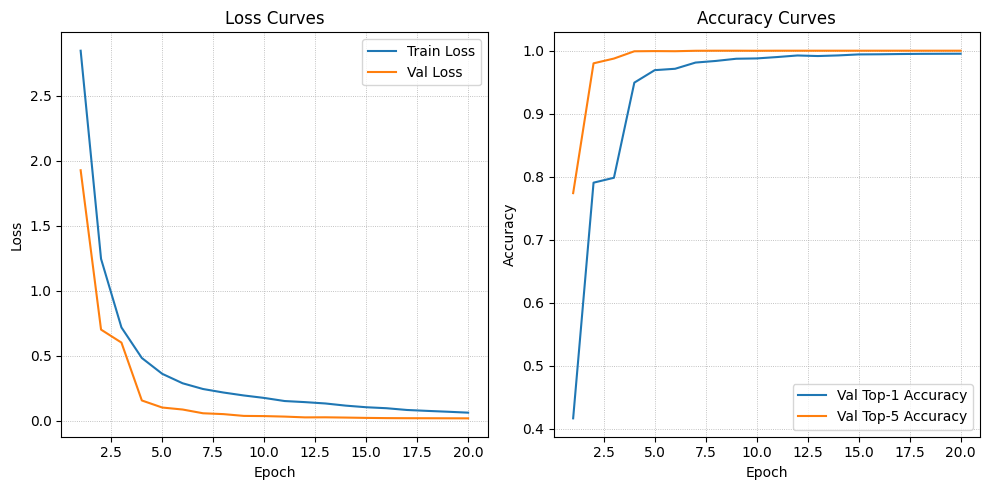


Learning curves saved to: /content/yolo_cls_runs/plantvillage_cls/analysis/learning_curves.png


In [17]:
#  Learning Curves (Train vs Val)
from pathlib import Path
import csv
import matplotlib.pyplot as plt

RUN_DIR = Path(PROJECT_DIR) / RUN_NAME
VAL_DIR = Path(PROJECT_DIR) / f"{RUN_NAME}_val"
TRAIN_CSV = RUN_DIR / "results.csv"
OUT_DIR   = RUN_DIR / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG   = OUT_DIR / "learning_curves.png"

def read_rows(csv_path: Path):
    if not csv_path.exists():
        print(f"CSV not found: {csv_path}")
        return []
    with csv_path.open() as f:
        return list(csv.DictReader(f))

def to_float(x):
    try:
        return float(x)
    except:
        return None

def pick(row, keys):
    for k in keys:
        if k in row and row[k] not in ("", None, "nan"):
            v = to_float(row[k])
            if v is not None:
                return v
    return None

# Flexible keys for YOLOv8 CSV columns
EPOCH_KEYS       = ["epoch", "Epoch"]
TRAIN_LOSS_KEYS  = ["train/loss", "loss", "train_loss"]
VAL_LOSS_KEYS    = ["val/loss", "metrics/loss", "val_loss"]
VAL_TOP1_KEYS    = ["metrics/accuracy_top1", "top1", "accuracy_top1"]
VAL_TOP5_KEYS    = ["metrics/accuracy_top5", "top5", "accuracy_top5"]
TRAIN_ACC_KEYS   = ["train/acc", "train/accuracy", "train_accuracy"]  # may not exist

rows = read_rows(TRAIN_CSV)
epochs, tr_loss, va_loss, tr_acc, va_acc1, va_acc5 = [], [], [], [], [], []

for i, r in enumerate(rows):
    ep = pick(r, EPOCH_KEYS)
    if ep is None:
        continue

    tr_l = pick(r, TRAIN_LOSS_KEYS)
    va_l = pick(r, VAL_LOSS_KEYS)
    va_a1 = pick(r, VAL_TOP1_KEYS)
    va_a5 = pick(r, VAL_TOP5_KEYS)

    # Collect points only if key values exist
    if tr_l is not None and va_l is not None and va_a1 is not None and va_a5 is not None:
        epochs.append(ep)
        tr_loss.append(tr_l)
        va_loss.append(va_l)
        va_acc1.append(va_a1)
        va_acc5.append(va_a5)

        # Train accuracy may not be available
        tr_a = pick(r, TRAIN_ACC_KEYS)
        tr_acc.append(tr_a if tr_a is not None else float('nan'))


# Plotting
plt.figure(figsize=(10, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, tr_loss, label="Train Loss")
plt.plot(epochs, va_loss, label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.6)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, va_acc1, label="Val Top-1 Accuracy")
plt.plot(epochs, va_acc5, label="Val Top-5 Accuracy")

# Plot train accuracy if available
if not all(np.isnan(tr_acc)):
     plt.plot(epochs, tr_acc, label="Train Accuracy (if available)", linestyle='--')

plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.6)

plt.tight_layout()
plt.savefig(OUT_PNG)
plt.show()

print("\nLearning curves saved to:", OUT_PNG)


100%|██████████| 1256/1256 [00:38<00:00, 32.22it/s]


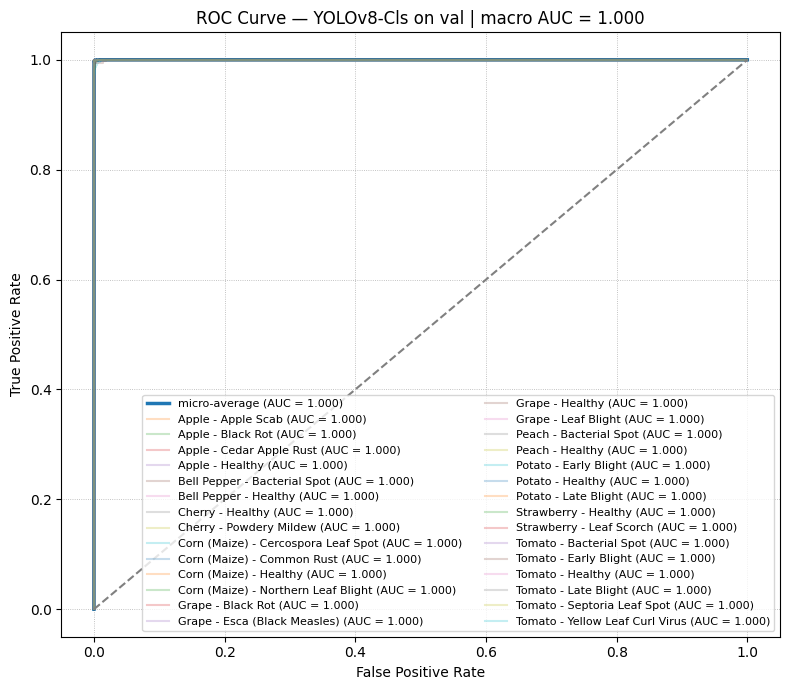

In [14]:

# ROC Curve   model YOLOv8-Classification

import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from torchvision import datasets, transforms
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm
import torch, gc
from pathlib import Path

# 1- Paths
BEST_WEIGHTS = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"
SPLIT_DIR    = DATA_DIR / "val"

assert BEST_WEIGHTS.exists(), f" Model weights not found: {BEST_WEIGHTS}"
assert SPLIT_DIR.exists(),    f" Directory not found: {SPLIT_DIR}"

# 2- Load model
model = YOLO(str(BEST_WEIGHTS))

# model.to('cpu')

# 3- Prepare data
imgsz = 224
transform = transforms.Compose([
    transforms.Resize((imgsz, imgsz)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(str(SPLIT_DIR), transform=transform)
class_names = dataset.classes
num_classes = len(class_names)

img_paths = [p for p, _ in dataset.samples]
y_true    = [y for _, y in dataset.samples]

assert len(img_paths) > 0, "No images found in the evaluation folder."

# 4- Predict probabilities in batches
torch.cuda.empty_cache(); gc.collect()

batch_size = 8
probs_list = []

for i in tqdm(range(0, len(img_paths), batch_size)):
    batch_paths = img_paths[i:i + batch_size]
    results = model.predict(source=batch_paths, imgsz=imgsz, stream=True, verbose=False)
    for r in results:
        if r.probs is None:
            raise RuntimeError(" r.probs not found — ensure the model is a classification model (yolov8*-cls).")
        probs_list.append(r.probs.data.detach().cpu().numpy())

P = np.vstack(probs_list)
Y = np.array(y_true)
Y_bin = label_binarize(Y, classes=list(range(num_classes)))

# 5- Compute ROC for each class + micro/macro
fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_bin[:, i], P[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_bin.ravel(), P.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
roc_auc["macro"] = np.mean(list(roc_auc.values()))

# 6- Plot ROC curves
plt.figure(figsize=(8,7))
plt.plot(fpr["micro"], tpr["micro"], linewidth=2.5,
         label=f"micro-average (AUC = {roc_auc['micro']:.3f})")

alpha_cls = 0.25 if num_classes > 8 else 0.6
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], alpha=alpha_cls, label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title(f"ROC Curve — YOLOv8-Cls on {SPLIT_DIR.name} | macro AUC = {roc_auc['macro']:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8, ncol=1 if num_classes < 10 else 2)
plt.grid(True, linestyle=":", linewidth=0.6)
plt.tight_layout()
plt.show()


In [18]:

# Precision / Recall / F1-Score for YOLOv8-Classification on test

from ultralytics import YOLO
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
from tqdm import tqdm
import numpy as np

# 1) Load model
BEST_WEIGHTS = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"
assert BEST_WEIGHTS.exists(), f"Model weights not found: {BEST_WEIGHTS}"
model = YOLO(str(BEST_WEIGHTS))


# 2) Define test folder (path correction)
EVAL_DIR = DATA_DIR / "test"
assert EVAL_DIR.exists(), f"Directory not found: {EVAL_DIR}"

# 3) Data preparation
imgsz = 224
transform = transforms.Compose([
    transforms.Resize((imgsz, imgsz)),
    transforms.ToTensor()
])
dataset = datasets.ImageFolder(str(EVAL_DIR), transform=transform)
class_names = dataset.classes
num_classes = len(class_names)
print(f"Number of images = {len(dataset)} | Number of classes = {num_classes}")

# 4) Predictions on test (small batches)
batch_size = 8
all_preds, all_true = [], []

for i in tqdm(range(0, len(dataset), batch_size)):
    batch_samples = dataset.samples[i:i + batch_size]
    img_paths = [p for p, _ in batch_samples]
    labels = [y for _, y in batch_samples]
    results = model.predict(source=img_paths, imgsz=imgsz, stream=True, verbose=False)

    for r, y in zip(results, labels):
        if r.probs is None:
            raise RuntimeError("Model is not classification (must be yolov8*-cls).")
        pred = int(torch.argmax(r.probs.data.detach().cpu()))
        all_preds.append(pred)
        all_true.append(y)

# 5) Performance report
print("\n==============================")
print("Performance Report on test")
print("==============================\n")
report = classification_report(all_true, all_preds, target_names=class_names, digits=4)
acc = accuracy_score(all_true, all_preds)
cm = confusion_matrix(all_true, all_preds)
print(report)
print(f"\nOverall Accuracy: {acc*100:.2f}%")

# 6) Quick sanity check
if acc > 0.99 and np.isclose(np.trace(cm), len(dataset)):
    print("The model is perfect on test — check for possible data leakage between train/test.")
else:
    print("Results look normal — no indication of data leakage.")


Number of images = 10038 | Number of classes = 29


100%|██████████| 1255/1255 [00:37<00:00, 33.61it/s]


Performance Report on test

                                     precision    recall  f1-score   support

                 Apple - Apple Scab     0.9974    1.0000    0.9987       378
                  Apple - Black Rot     1.0000    1.0000    1.0000       372
           Apple - Cedar Apple Rust     1.0000    1.0000    1.0000       326
                    Apple - Healthy     0.9973    0.9920    0.9947       375
       Bell Pepper - Bacterial Spot     0.9917    1.0000    0.9958       358
              Bell Pepper - Healthy     0.9946    0.9946    0.9946       372
                   Cherry - Healthy     0.9971    0.9913    0.9942       343
            Cherry - Powdery Mildew     1.0000    1.0000    1.0000       315
Corn (Maize) - Cercospora Leaf Spot     0.9832    0.9481    0.9653       308
         Corn (Maize) - Common Rust     0.9916    0.9972    0.9944       357
             Corn (Maize) - Healthy     1.0000    1.0000    1.0000       349
Corn (Maize) - Northern Leaf Blight     0.9645

TEST samples = 10038 | classes = 29


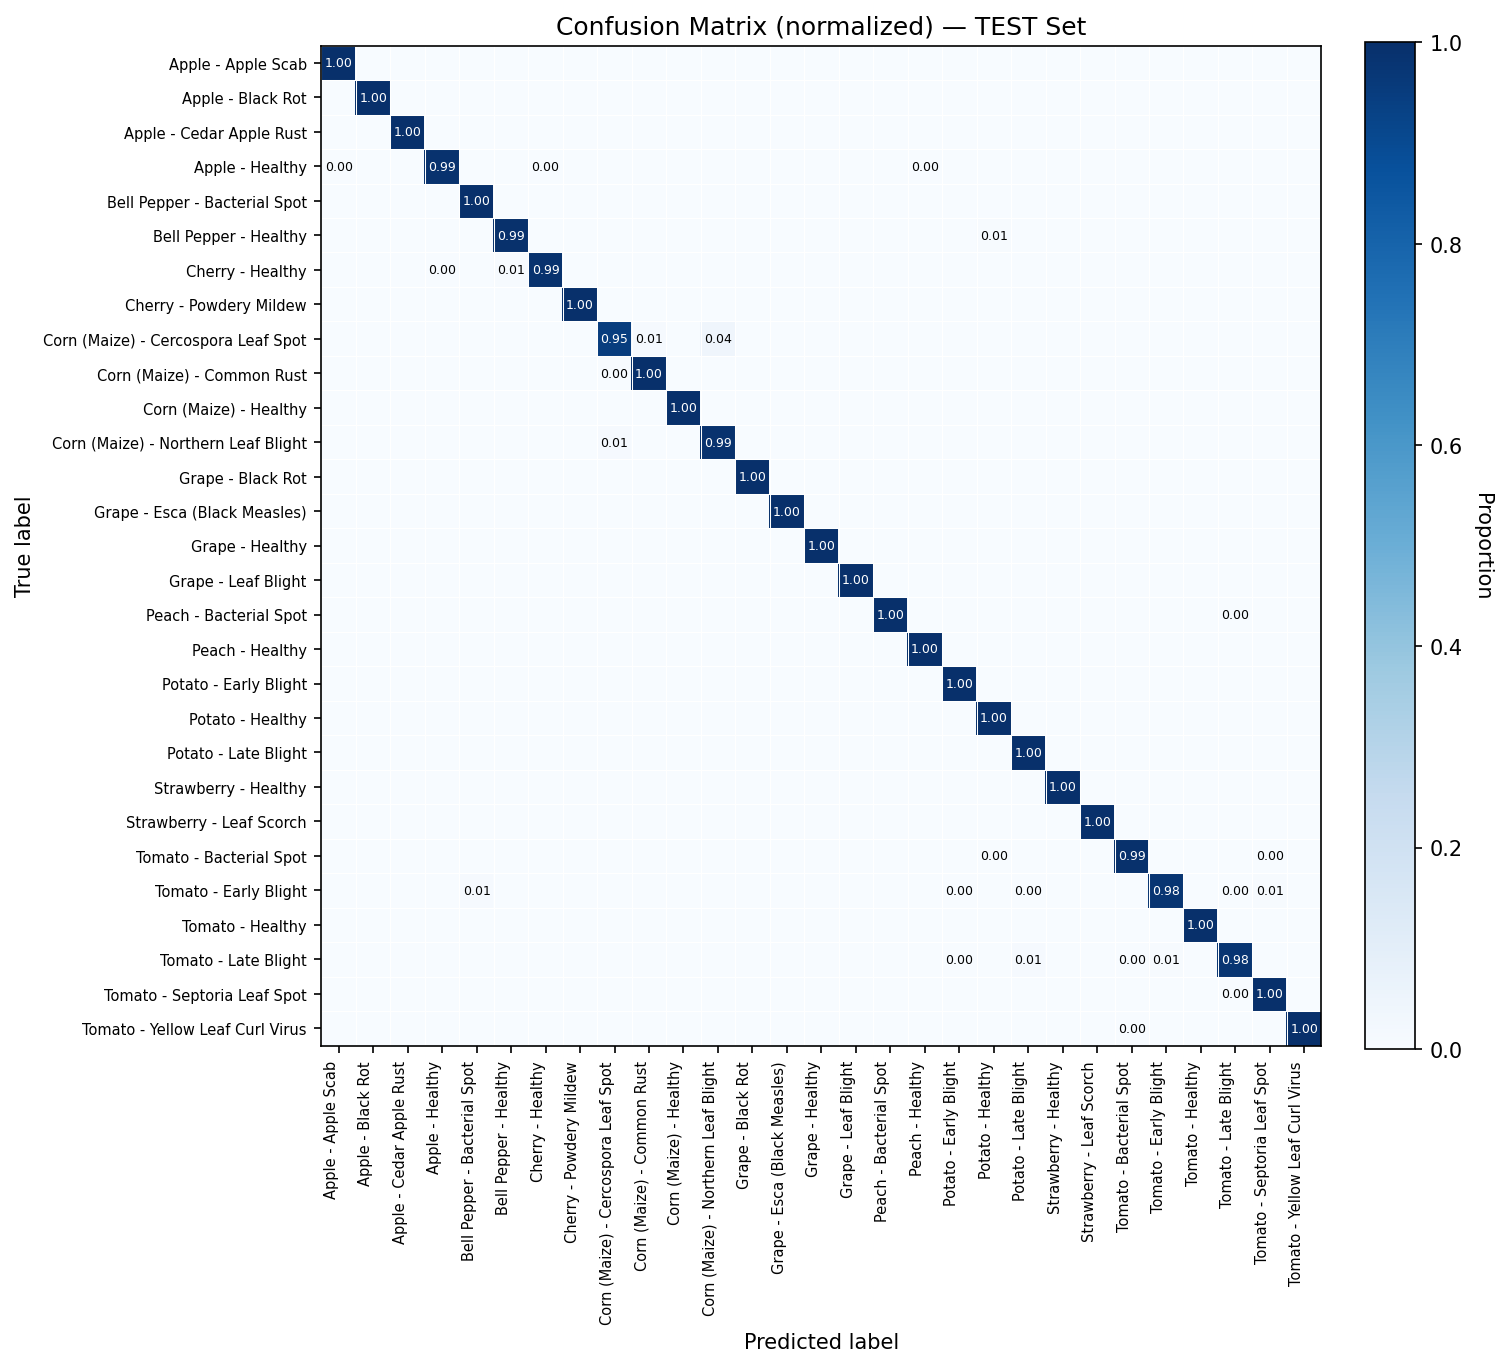

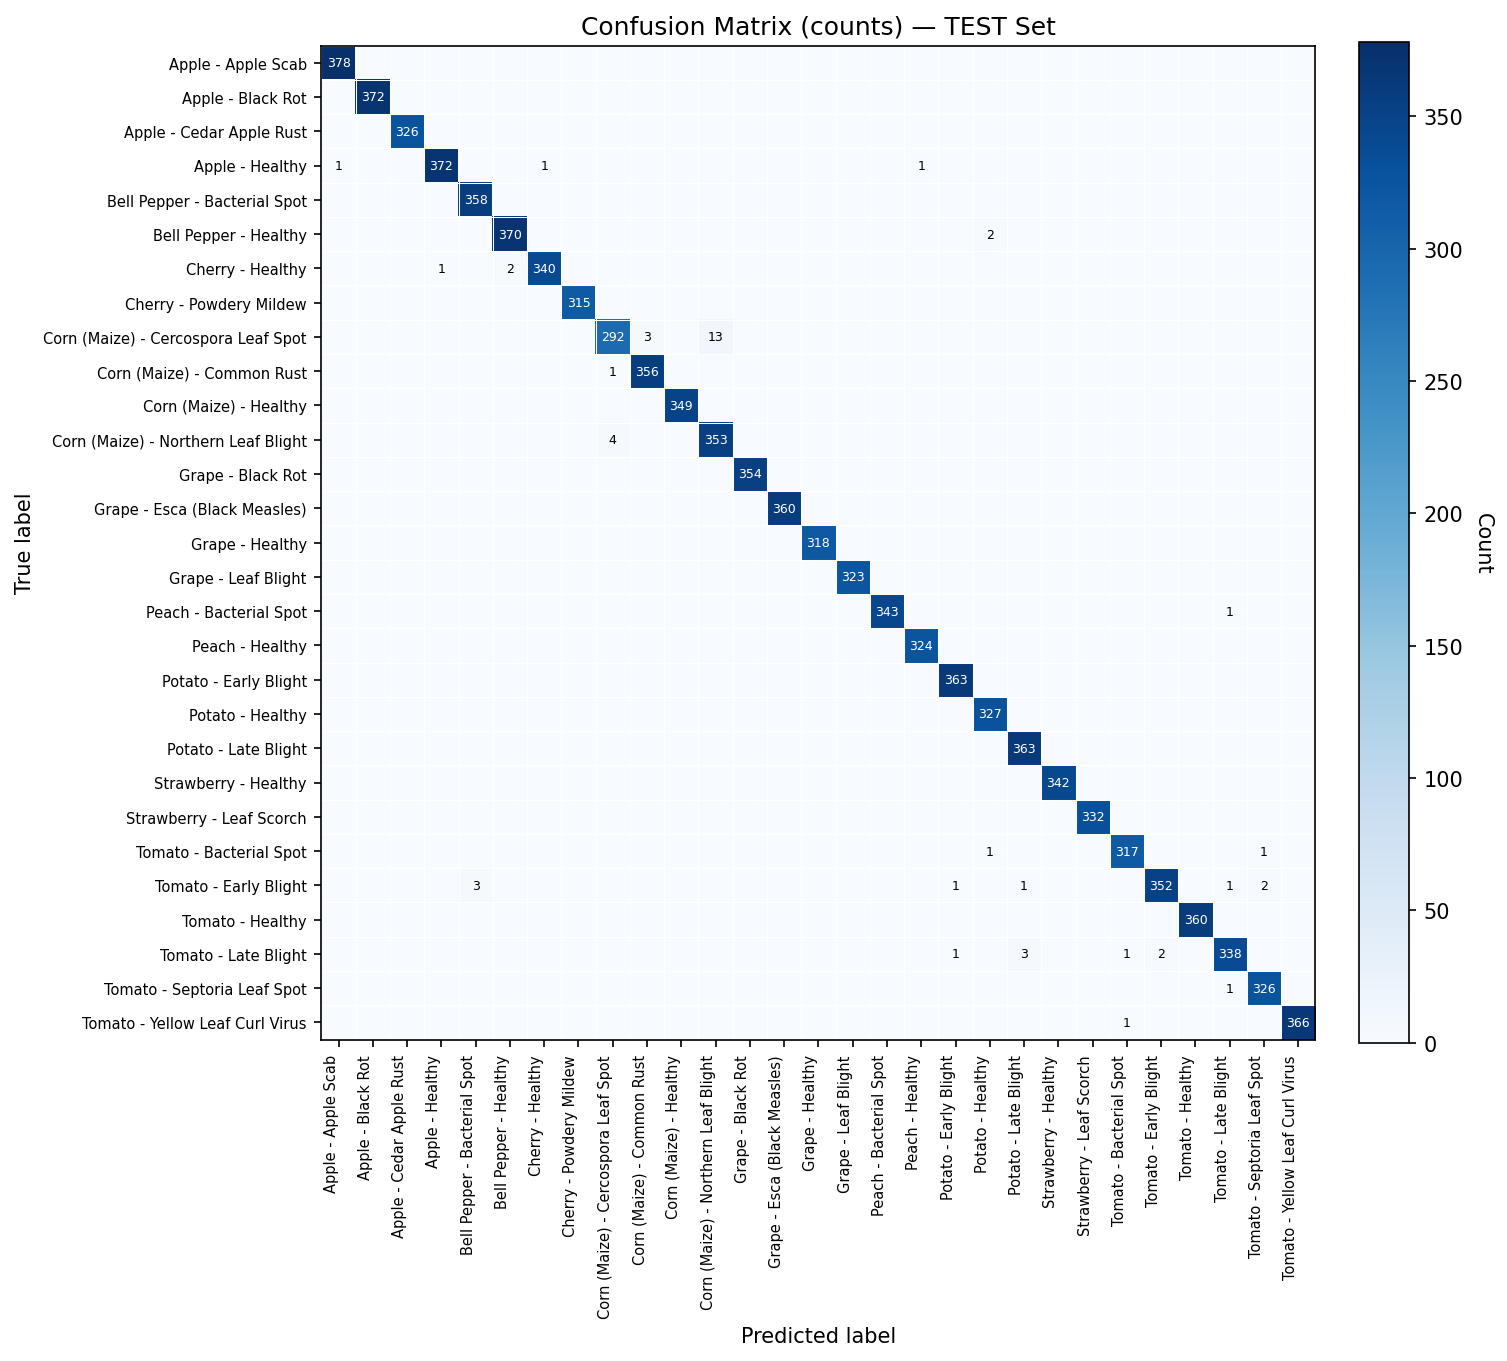

TEST accuracy = 99.51%
Saved: /content/confusion_matrix_test_normalized.png and /content/confusion_matrix_test_counts.png


In [19]:

# Confusion Matrix on the TEST set — YOLOv8/YOLO11-Classification


from ultralytics import YOLO
from torchvision import datasets
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1) Paths
BEST_WEIGHTS = Path("/content/yolo_cls_runs/plantvillage_cls/weights/best.pt")
TEST_DIR     = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15/test")
IMG_SIZE     = 224
DEVICE       = 0

assert BEST_WEIGHTS.exists(), f"Model weights not found: {BEST_WEIGHTS}"
assert TEST_DIR.exists(),     f"TEST directory not found: {TEST_DIR}"

# 2) Load TEST dataset (ImageFolder uses alphabetical class order)
test_ds = datasets.ImageFolder(str(TEST_DIR))
ds_names = test_ds.classes
paths    = [p for p,_ in test_ds.samples]
y_true   = [y for _,y in test_ds.samples]
n_classes = len(ds_names)
print(f"TEST samples = {len(paths)} | classes = {n_classes}")

# 3) Load model and run predictions on TEST
model = YOLO(str(BEST_WEIGHTS))

y_pred_model_idx = []
for i in range(0, len(paths), 64):
    batch_paths = paths[i:i+64]
    results = model.predict(batch_paths, imgsz=IMG_SIZE, device=DEVICE, verbose=False)
    for r in results:
        y_pred_model_idx.append(int(r.probs.top1))   # predicted class index from model

# 4) Align class index order (critical for correct CM rows/columns)
model_names = [model.names[i] for i in range(len(model.names))]
assert set(model_names) == set(ds_names), "Model class names do not match dataset class names!"

# Mapping: model_index -> ImageFolder_index
model_to_ds_idx = {mi: ds_names.index(name) for mi, name in enumerate(model_names)}
y_pred = [model_to_ds_idx[p] for p in y_pred_model_idx]

assert len(y_pred) == len(y_true), "y_pred length does not match y_true!"

# 5) Generic confusion matrix plot function
def plot_confmat(cm, class_names, title, out_path, normalized):
    fig, ax = plt.subplots(figsize=(max(9, n_classes*0.35), max(9, n_classes*0.35)), dpi=150)
    vmin, vmax = (0, 1) if normalized else (0, max(1, cm.max()))
    im = ax.imshow(cm, cmap="Blues", vmin=vmin, vmax=vmax, interpolation="nearest")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proportion" if normalized else "Count", rotation=270, labelpad=14)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(n_classes)); ax.set_yticks(np.arange(n_classes))
    fsz = 7 if n_classes <= 40 else 6
    ax.set_xticklabels(class_names, rotation=90, ha="right", fontsize=fsz)
    ax.set_yticklabels(class_names, fontsize=fsz)

    # Light grid
    ax.set_xticks(np.arange(-.5, n_classes, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n_classes, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate values in cells
    fmt = ".2f" if normalized else "d"
    thresh = 0.5 if normalized else (cm.max()/2 if cm.max()>0 else 0.5)
    for i in range(n_classes):
        for j in range(n_classes):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, format(v, fmt),
                        ha="center", va="center",
                        color=("white" if v >= thresh else "black"),
                        fontsize=6)

    plt.tight_layout()
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# 6) Compute confusion matrix (counts + normalized) on TEST
cm_counts = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
row_sums  = cm_counts.sum(axis=1, keepdims=True).astype(float)
row_sums[row_sums == 0] = 1.0
cm_norm   = (cm_counts.astype(float) / row_sums)

# 7) Plot and save
plot_confmat(cm_norm,   ds_names, "Confusion Matrix (normalized) — TEST Set",
             "/content/confusion_matrix_test_normalized.png", normalized=True)
plot_confmat(cm_counts, ds_names, "Confusion Matrix (counts) — TEST Set",
             "/content/confusion_matrix_test_counts.png", normalized=False)

# 8) Quick check
acc = (np.array(y_true) == np.array(y_pred)).mean()
print(f"TEST accuracy = {acc*100:.2f}%")
print("Saved:",
      "/content/confusion_matrix_test_normalized.png",
      "and",
      "/content/confusion_matrix_test_counts.png")
